In [1]:
# ---- average CRPS per cluster, per chunk_size, for every cluster file in ----
# ---- ../data/regime_labels/ ----
# Each file there is (season, n_clusters) -> cluster centroids (cluster, longitude, latitude).
# Its coordinates don't exactly match the fine-grained lat/lon in the CRPS CSVs,
# so we spatial-join: for each CRPS row (hemisphere-corrected season), assign it
# to the nearest cluster centroid via cKDTree, then average PER chunk_size --
# CRPS scales differ a lot by chunk_size (5 vs 10 vs 21), so pooling them
# together would wash out real per-chunk_size cluster differences.

import glob
import csv
import re
from datetime import date, timedelta

import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

DATA_START_DATE = date(2011, 9, 10)


def index_to_season(start_idx, chunk_size, lat):
    mid_idx = start_idx + chunk_size // 2
    d = DATA_START_DATE + timedelta(days=int(mid_idx))
    month = d.month
    is_northern = lat >= 0
    if is_northern:
        if month in (1, 2, 3):
            return "winter"
        elif month in (8, 9, 10):
            return "summer"
    else:
        if month in (1, 2, 3):
            return "summer"
        elif month in (8, 9, 10):
            return "winter"
    return "other"


def load_and_relabel(csv_path):
    """Read a CRPS results CSV and recompute season correctly from lat + start.
    Does not modify the file on disk."""
    rows = []
    with open(csv_path, newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            lat = float(row["lat"])
            start = int(row["start"])
            chunk_size = int(row["chunk_size"])
            row["lat"] = lat
            row["lon"] = float(row["lon"])
            row["crps"] = float(row["crps"])
            row["season"] = index_to_season(start, chunk_size, lat)  # corrected, in-memory only
            rows.append(row)
    return rows


# load hemisphere-corrected CRPS rows once, split by chunk_size
crps_rows_by_chunk_size = {}
for chunk_size in (5, 10, 21):
    merged = (
        load_and_relabel(f"../data/derived_crps/crps_results_chunk{chunk_size}_winter.csv")
        + load_and_relabel(f"../data/derived_crps/crps_results_chunk{chunk_size}_summer.csv")
    )
    crps_rows_by_chunk_size[chunk_size] = pd.DataFrame(merged)[["lat", "lon", "season", "crps"]]

CLUSTER_FILE_RE = re.compile(r"cluster_coords_(?P<season>winter|summer)_nclusters(?P<n>\d+)\.csv")

cluster_files = sorted(glob.glob("../data/regime_labels/cluster_coords_*_nclusters*.csv"))
print(f"Found {len(cluster_files)} cluster files")

# cluster_avg_results[(season, n_clusters)] -> DataFrame indexed by (chunk_size, cluster)
# with mean_crps/std_crps/n
cluster_avg_results = {}

for path in cluster_files:
    m = CLUSTER_FILE_RE.search(path)
    if not m:
        raise ValueError(f"Could not parse season/n_clusters from filename: {path}")
    season = m["season"]
    n_clusters = int(m["n"])

    cluster_df = pd.read_csv(path)
    cluster_coords = cluster_df[["longitude", "latitude"]].to_numpy()
    cluster_ids_ref = cluster_df["cluster"].to_numpy()
    cluster_tree = cKDTree(cluster_coords)

    per_chunk_size_rows = []
    for chunk_size, crps_df in crps_rows_by_chunk_size.items():
        season_df = crps_df[crps_df["season"] == season].copy()
        query_coords = season_df[["lon", "lat"]].to_numpy()
        _, nearest_idx = cluster_tree.query(query_coords)
        season_df["cluster"] = cluster_ids_ref[nearest_idx]
        season_df["chunk_size"] = chunk_size
        per_chunk_size_rows.append(season_df)

    combined = pd.concat(per_chunk_size_rows, ignore_index=True)
    summary = (
        combined.groupby(["chunk_size", "cluster"])["crps"]
        .agg(mean_crps="mean", std_crps="std", n="count")
        .sort_index()
    )
    cluster_avg_results[(season, n_clusters)] = summary
    print(f"season={season:6s} n_clusters={n_clusters}: computed cluster averages for chunk_sizes 5,10,21")

Found 12 cluster files
season=summer n_clusters=3: computed cluster averages for chunk_sizes 5,10,21
season=summer n_clusters=4: computed cluster averages for chunk_sizes 5,10,21
season=summer n_clusters=5: computed cluster averages for chunk_sizes 5,10,21
season=summer n_clusters=6: computed cluster averages for chunk_sizes 5,10,21
season=summer n_clusters=7: computed cluster averages for chunk_sizes 5,10,21
season=summer n_clusters=8: computed cluster averages for chunk_sizes 5,10,21
season=winter n_clusters=3: computed cluster averages for chunk_sizes 5,10,21
season=winter n_clusters=4: computed cluster averages for chunk_sizes 5,10,21
season=winter n_clusters=5: computed cluster averages for chunk_sizes 5,10,21
season=winter n_clusters=6: computed cluster averages for chunk_sizes 5,10,21
season=winter n_clusters=7: computed cluster averages for chunk_sizes 5,10,21
season=winter n_clusters=8: computed cluster averages for chunk_sizes 5,10,21


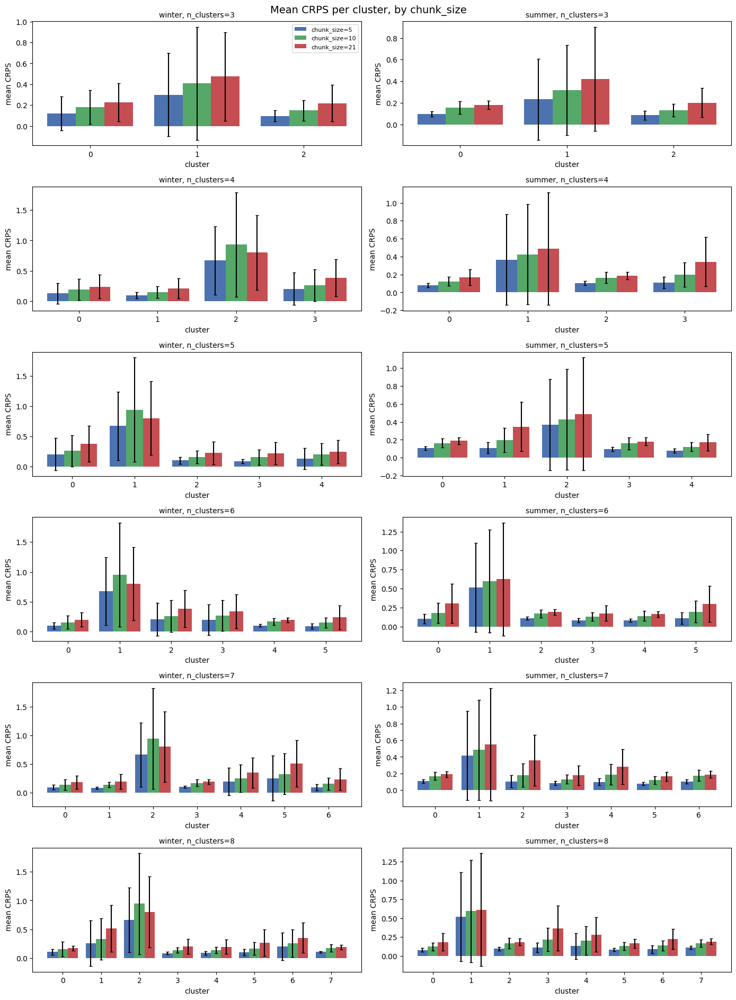

In [2]:
# ---- plot mean CRPS per cluster, one subplot per (season, n_clusters) file ----
# each subplot: x-axis = cluster id, grouped bars = chunk_size, y-axis = mean CRPS
# (error bars = std_crps), so you can see how cluster-wise CRPS changes with
# chunk_size within a given clustering, and compare across n_clusters/season.

import matplotlib.pyplot as plt
import numpy as np

seasons = ["winter", "summer"]
n_clusters_list = sorted({n for (_, n) in cluster_avg_results.keys()})
chunk_sizes = [5, 10, 21]
chunk_colors = {5: "#4c72b0", 10: "#55a868", 21: "#c44e52"}

fig, axes = plt.subplots(len(n_clusters_list), len(seasons),
                          figsize=(7 * len(seasons), 3.2 * len(n_clusters_list)),
                          squeeze=False)

for row_idx, n_clusters in enumerate(n_clusters_list):
    for col_idx, season in enumerate(seasons):
        ax = axes[row_idx, col_idx]
        key = (season, n_clusters)
        if key not in cluster_avg_results:
            ax.set_visible(False)
            continue

        summary = cluster_avg_results[key]
        cluster_ids = sorted(summary.index.get_level_values("cluster").unique())
        n_groups = len(chunk_sizes)
        bar_width = 0.8 / n_groups
        x = np.arange(len(cluster_ids))

        for i, chunk_size in enumerate(chunk_sizes):
            means, stds = [], []
            for c in cluster_ids:
                if (chunk_size, c) in summary.index:
                    means.append(summary.loc[(chunk_size, c), "mean_crps"])
                    stds.append(summary.loc[(chunk_size, c), "std_crps"])
                else:
                    means.append(0.0)
                    stds.append(0.0)
            offset = (i - (n_groups - 1) / 2) * bar_width
            ax.bar(x + offset, means, width=bar_width, yerr=stds, capsize=2,
                   color=chunk_colors[chunk_size], label=f"chunk_size={chunk_size}")

        ax.set_xticks(x)
        ax.set_xticklabels(cluster_ids)
        ax.set_xlabel("cluster")
        ax.set_ylabel("mean CRPS")
        ax.set_title(f"{season}, n_clusters={n_clusters}", fontsize=10)
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=8)

plt.suptitle("Mean CRPS per cluster, by chunk_size", fontsize=14)
plt.tight_layout()
plt.savefig("crps_cluster_mean_by_chunk_size_all.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_4025891/3538198631.py:93: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS")
/tmp/ipykernel_4025891/3538198631.py:93: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS")
/tmp/ipykernel_4025891/3538198631.py:93: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS")
/tmp/ipykernel_4025891/3538198631.py:93: MatplotlibDepr

Saved: crps_cluster_map_chunk5.png


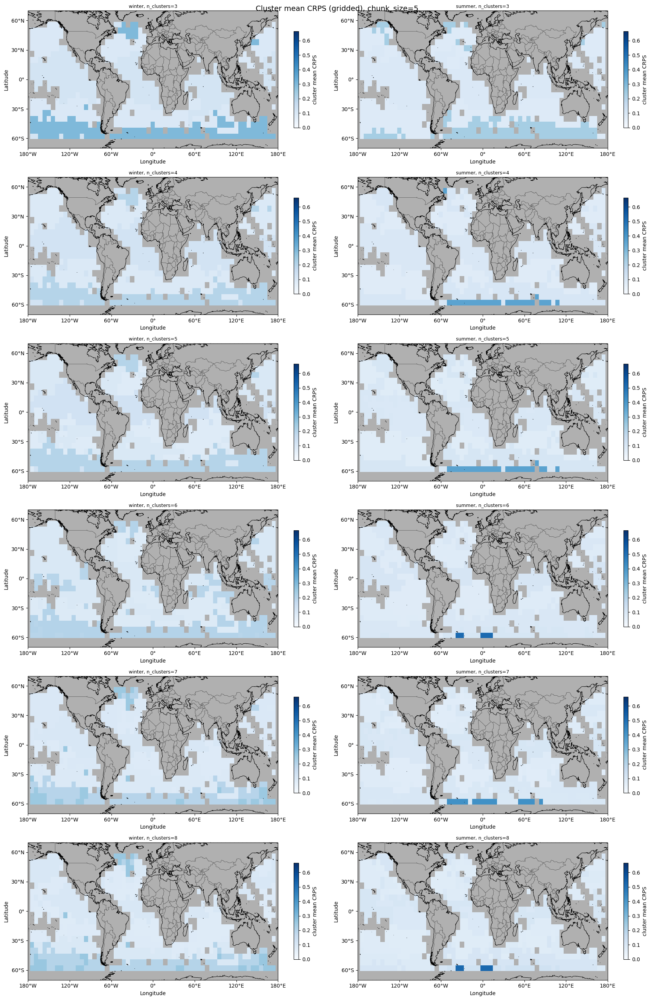

/tmp/ipykernel_4025891/3538198631.py:93: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS")
/tmp/ipykernel_4025891/3538198631.py:93: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS")
/tmp/ipykernel_4025891/3538198631.py:93: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS")
/tmp/ipykernel_4025891/3538198631.py:93: MatplotlibDepr

Saved: crps_cluster_map_chunk10.png


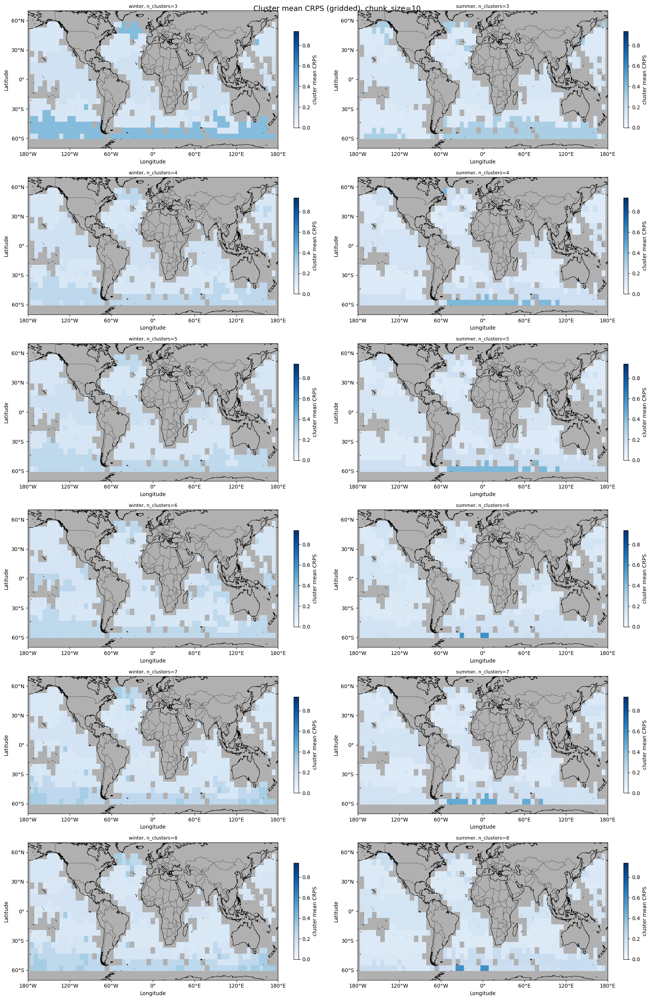

/tmp/ipykernel_4025891/3538198631.py:93: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS")
/tmp/ipykernel_4025891/3538198631.py:93: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS")
/tmp/ipykernel_4025891/3538198631.py:93: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS")
/tmp/ipykernel_4025891/3538198631.py:93: MatplotlibDepr

Saved: crps_cluster_map_chunk21.png


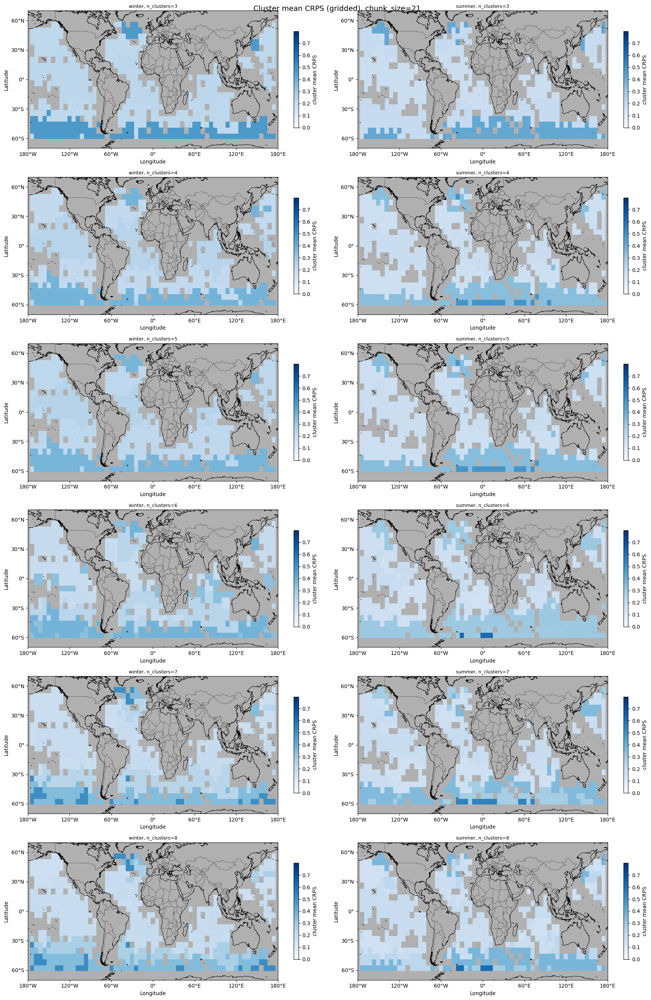

In [7]:
# ---- map view: gridded/pcolor style, matching the Blues CRPS maps ----
# Same pcolor + coastlines + gray "too far"/land masking style as
# plot_global_crps_relabeled_no_outliers.py, but colored by cluster mean CRPS
# (each cluster's assigned points get their cluster's mean value before
# gridding, so each cluster's region reads as one flat color).
# One figure per chunk_size (CRPS scales aren't comparable across chunk_size).

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
from matplotlib.colors import ListedColormap
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

DX = 6.0
LAT_CUTOFF_GRID = 60
DIST_THRESHOLD = 6.0

loni = np.arange(-180, 180 + DX, DX)
lati = np.arange(-70, 70 + DX, DX)
long, latg = np.meshgrid(loni, lati)
grid_points = np.column_stack([long.ravel(), latg.ravel()])

mask_data = np.load("../data/derived_crps/mask_to_plot_ratio.npz")
grid_mask = mask_data["mask"][:, :]
beyond_cutoff_grid = np.abs(lati) > LAT_CUTOFF_GRID
gray_cmap = ListedColormap(["#b0b0b0"])

# recompute the raw (season, n_clusters, chunk_size) -> assigned points with cluster + crps,
# reusing the same spatial join as the summary cell so maps and bar charts agree
assigned_points = {}  # (season, n_clusters, chunk_size) -> DataFrame [lat, lon, cluster, crps]

for path in cluster_files:
    m = CLUSTER_FILE_RE.search(path)
    season = m["season"]
    n_clusters = int(m["n"])

    cluster_df = pd.read_csv(path)
    cluster_coords = cluster_df[["longitude", "latitude"]].to_numpy()
    cluster_ids_ref = cluster_df["cluster"].to_numpy()
    cluster_tree = cKDTree(cluster_coords)

    for chunk_size, crps_df in crps_rows_by_chunk_size.items():
        season_df = crps_df[crps_df["season"] == season].copy()
        query_coords = season_df[["lon", "lat"]].to_numpy()
        _, nearest_idx = cluster_tree.query(query_coords)
        season_df["cluster"] = cluster_ids_ref[nearest_idx]
        assigned_points[(season, n_clusters, chunk_size)] = season_df[["lat", "lon", "cluster", "crps"]]

proj = ccrs.PlateCarree()

for chunk_size in chunk_sizes:
    fig, axes = plt.subplots(len(n_clusters_list), len(seasons),
                              figsize=(9 * len(seasons), 4.5 * len(n_clusters_list)),
                              subplot_kw={"projection": proj}, squeeze=False)

    # shared color scale across this chunk_size's panels, so cluster colors are comparable
    all_cluster_means = []
    for n_clusters in n_clusters_list:
        for season in seasons:
            summary = cluster_avg_results[(season, n_clusters)]
            if chunk_size in summary.index.get_level_values("chunk_size"):
                all_cluster_means.extend(summary.loc[chunk_size, "mean_crps"].values)
    vmax = np.percentile(all_cluster_means, 95)

    for row_idx, n_clusters in enumerate(n_clusters_list):
        for col_idx, season in enumerate(seasons):
            ax = axes[row_idx, col_idx]
            pts = assigned_points[(season, n_clusters, chunk_size)]
            summary = cluster_avg_results[(season, n_clusters)]

            cluster_mean_lookup = summary.loc[chunk_size, "mean_crps"].to_dict()
            point_vals = pts["cluster"].map(cluster_mean_lookup).to_numpy()

            coordinate = np.column_stack([pts["lon"].to_numpy(), pts["lat"].to_numpy()])
            gridded = griddata(coordinate, point_vals, (long, latg), method="nearest")

            tree = cKDTree(coordinate)
            dist_to_nearest, _ = tree.query(grid_points)
            too_far = dist_to_nearest.reshape(long.shape) > DIST_THRESHOLD
            gridded[too_far] = np.nan

            gridded = gridded * grid_mask
            gridded[grid_mask == 0] = np.nan
            gridded[beyond_cutoff_grid, :] = np.nan

            grayed_out = np.full_like(grid_mask, np.nan, dtype=float)
            grayed_out[grid_mask == 0] = 1.0
            grayed_out[beyond_cutoff_grid, :] = 1.0
            grayed_out[too_far] = 1.0

            mesh = ax.pcolor(loni, lati, gridded, cmap="Blues", vmin=0, vmax=vmax,
                              transform=proj)
            plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS")

            ax.pcolor(loni, lati, grayed_out, cmap=gray_cmap, vmin=0, vmax=1, transform=proj)

            ax.coastlines(resolution="50m", linewidth=0.7, color="black")
            ax.add_feature(cfeature.BORDERS, linewidth=0.3, zorder=2)
            ax.set_xticks(np.arange(-180, 181, 60), crs=proj)
            ax.set_yticks(np.arange(-60, 61, 30), crs=proj)
            ax.xaxis.set_major_formatter(LONGITUDE_FORMATTER)
            ax.yaxis.set_major_formatter(LATITUDE_FORMATTER)

            ax.set_title(f"{season}, n_clusters={n_clusters}", fontsize=9)
            ax.set_xlabel("Longitude")
            ax.set_ylabel("Latitude")
            ax.set_extent([-180, 180, -70, 70], crs=proj)
            ax.set_aspect("auto")

    plt.suptitle(f"Cluster mean CRPS (gridded), chunk_size={chunk_size}", fontsize=14)
    plt.tight_layout()
    out_path = f"crps_cluster_map_chunk{chunk_size}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.show()

/tmp/ipykernel_2656435/86009847.py:109: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS",
/tmp/ipykernel_2656435/86009847.py:109: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS",
/tmp/ipykernel_2656435/86009847.py:109: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS",
/tmp/ipykernel_2656435/86009847.py:10

Saved: crps_cluster_map_chunk5.png


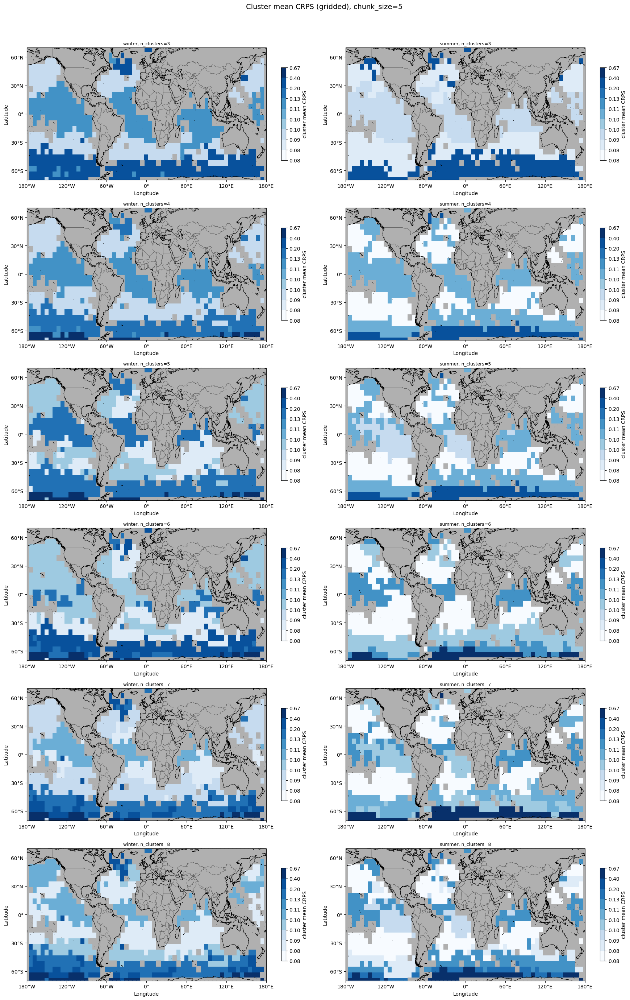

/tmp/ipykernel_2656435/86009847.py:109: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS",
/tmp/ipykernel_2656435/86009847.py:109: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS",
/tmp/ipykernel_2656435/86009847.py:109: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS",
/tmp/ipykernel_2656435/86009847.py:10

Saved: crps_cluster_map_chunk10.png


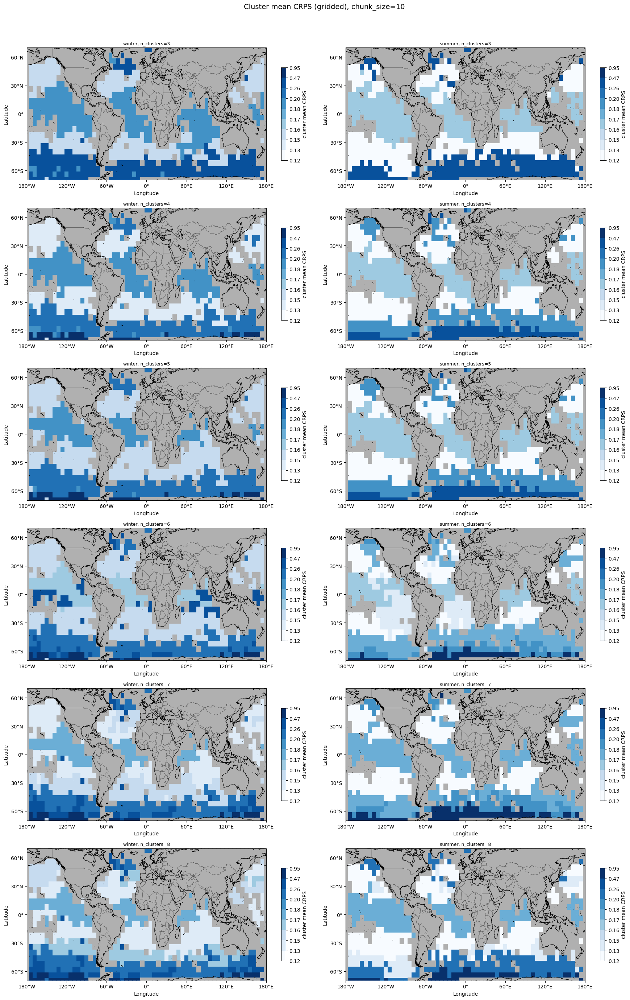

/tmp/ipykernel_2656435/86009847.py:109: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS",
/tmp/ipykernel_2656435/86009847.py:109: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS",
/tmp/ipykernel_2656435/86009847.py:109: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS",
/tmp/ipykernel_2656435/86009847.py:10

Saved: crps_cluster_map_chunk21.png


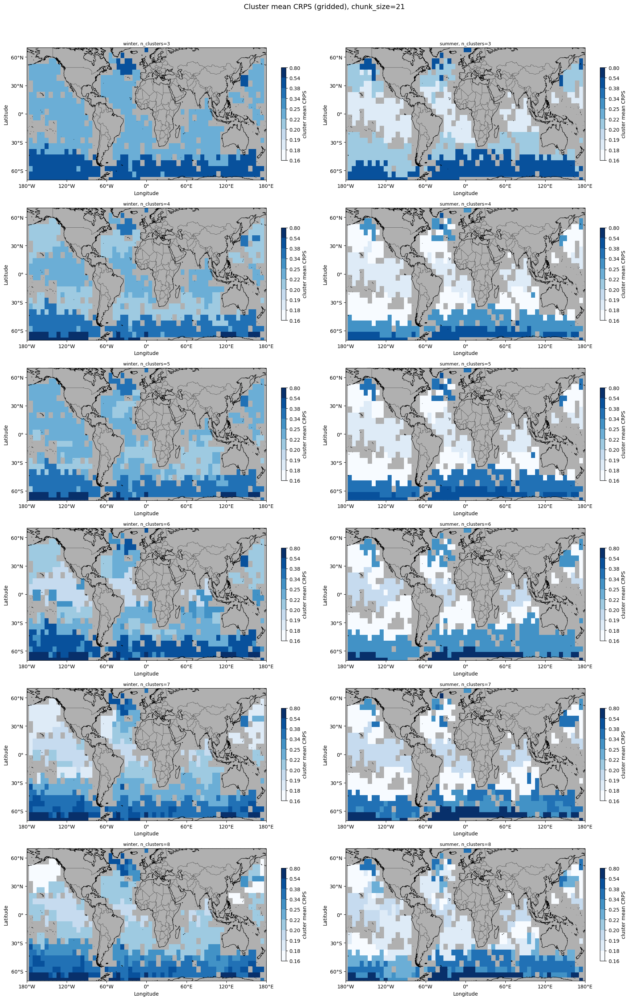

In [6]:
# ---- map view: gridded/pcolor style, matching the Blues CRPS maps ----
# Same pcolor + coastlines + gray "too far"/land masking style as
# plot_global_crps_relabeled_no_outliers.py, but colored by cluster mean CRPS
# (each cluster's assigned points get their cluster's mean value before
# gridding, so each cluster's region reads as one flat color).
# One figure per chunk_size (CRPS scales aren't comparable across chunk_size).
#
# Color scale is discretized (BoundaryNorm) rather than continuous: with only
# a handful of clusters per panel, a continuous Blues gradient makes
# neighboring clusters whose means are close look like the same shade. Binning
# into N_COLOR_BINS quantile-spaced bins forces visibly distinct steps.

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
from matplotlib.colors import ListedColormap, BoundaryNorm
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

DX = 6.0
LAT_CUTOFF_GRID = 80
DIST_THRESHOLD = 6.0
N_COLOR_BINS = 9

loni = np.arange(-180, 180 + DX, DX)
lati = np.arange(-70, 70 + DX, DX)
long, latg = np.meshgrid(loni, lati)
grid_points = np.column_stack([long.ravel(), latg.ravel()])

mask_data = np.load("../data/derived_crps/mask_to_plot_ratio.npz")
grid_mask = mask_data["mask"][:, :]
beyond_cutoff_grid = np.abs(lati) > LAT_CUTOFF_GRID
gray_cmap = ListedColormap(["#b0b0b0"])

# recompute the raw (season, n_clusters, chunk_size) -> assigned points with cluster + crps,
# reusing the same spatial join as the summary cell so maps and bar charts agree
assigned_points = {}  # (season, n_clusters, chunk_size) -> DataFrame [lat, lon, cluster, crps]

for path in cluster_files:
    m = CLUSTER_FILE_RE.search(path)
    season = m["season"]
    n_clusters = int(m["n"])

    cluster_df = pd.read_csv(path)
    cluster_coords = cluster_df[["longitude", "latitude"]].to_numpy()
    cluster_ids_ref = cluster_df["cluster"].to_numpy()
    cluster_tree = cKDTree(cluster_coords)

    for chunk_size, crps_df in crps_rows_by_chunk_size.items():
        season_df = crps_df[crps_df["season"] == season].copy()
        query_coords = season_df[["lon", "lat"]].to_numpy()
        _, nearest_idx = cluster_tree.query(query_coords)
        season_df["cluster"] = cluster_ids_ref[nearest_idx]
        assigned_points[(season, n_clusters, chunk_size)] = season_df[["lat", "lon", "cluster", "crps"]]

proj = ccrs.PlateCarree()

for chunk_size in chunk_sizes:
    fig, axes = plt.subplots(len(n_clusters_list), len(seasons),
                              figsize=(9 * len(seasons), 4.5 * len(n_clusters_list)),
                              subplot_kw={"projection": proj}, squeeze=False)

    # shared color scale across this chunk_size's panels, so cluster colors are comparable
    all_cluster_means = []
    for n_clusters in n_clusters_list:
        for season in seasons:
            summary = cluster_avg_results[(season, n_clusters)]
            if chunk_size in summary.index.get_level_values("chunk_size"):
                all_cluster_means.extend(summary.loc[chunk_size, "mean_crps"].values)

    # quantile-spaced bin edges so each bin holds roughly equal numbers of
    # cluster-means, keeping the discrete steps well spread out even when the
    # underlying values are skewed
    quantiles = np.linspace(0, 1, N_COLOR_BINS + 1)
    bin_edges = np.unique(np.quantile(all_cluster_means, quantiles))
    if len(bin_edges) < 3:
        # degenerate case: not enough distinct values to bin meaningfully
        bin_edges = np.linspace(min(all_cluster_means), max(all_cluster_means) + 1e-9, 3)
    discrete_cmap = plt.get_cmap("Blues", len(bin_edges) - 1)
    norm = BoundaryNorm(bin_edges, discrete_cmap.N)

    for row_idx, n_clusters in enumerate(n_clusters_list):
        for col_idx, season in enumerate(seasons):
            ax = axes[row_idx, col_idx]
            pts = assigned_points[(season, n_clusters, chunk_size)]
            summary = cluster_avg_results[(season, n_clusters)]

            cluster_mean_lookup = summary.loc[chunk_size, "mean_crps"].to_dict()
            point_vals = pts["cluster"].map(cluster_mean_lookup).to_numpy()

            coordinate = np.column_stack([pts["lon"].to_numpy(), pts["lat"].to_numpy()])
            gridded = griddata(coordinate, point_vals, (long, latg), method="nearest")

            tree = cKDTree(coordinate)
            dist_to_nearest, _ = tree.query(grid_points)
            too_far = dist_to_nearest.reshape(long.shape) > DIST_THRESHOLD
            gridded[too_far] = np.nan

            gridded = gridded * grid_mask
            gridded[grid_mask == 0] = np.nan
            gridded[beyond_cutoff_grid, :] = np.nan

            grayed_out = np.full_like(grid_mask, np.nan, dtype=float)
            grayed_out[grid_mask == 0] = 1.0
            grayed_out[beyond_cutoff_grid, :] = 1.0
            grayed_out[too_far] = 1.0

            mesh = ax.pcolor(loni, lati, gridded, cmap=discrete_cmap, norm=norm,
                              transform=proj)
            cbar = plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS",
                                 boundaries=bin_edges, ticks=bin_edges)
            cbar.ax.set_yticklabels([f"{v:.2f}" for v in bin_edges])


            ax.pcolor(loni, lati, grayed_out, cmap=gray_cmap, vmin=0, vmax=1, transform=proj)

            ax.coastlines(resolution="50m", linewidth=0.7, color="black")
            ax.add_feature(cfeature.BORDERS, linewidth=0.3, zorder=2)
            ax.set_xticks(np.arange(-180, 181, 60), crs=proj)
            ax.set_yticks(np.arange(-60, 61, 30), crs=proj)
            ax.xaxis.set_major_formatter(LONGITUDE_FORMATTER)
            ax.yaxis.set_major_formatter(LATITUDE_FORMATTER)

            ax.set_title(f"{season}, n_clusters={n_clusters}", fontsize=9)
            ax.set_xlabel("Longitude")
            ax.set_ylabel("Latitude")
            ax.set_extent([-180, 180, -70, 70], crs=proj)
            ax.set_aspect("auto")

    plt.suptitle(f"Cluster mean CRPS (gridded), chunk_size={chunk_size}", fontsize=14)
    plt.suptitle(f"Cluster mean CRPS (gridded), chunk_size={chunk_size}", fontsize=14, y=1.02)
    plt.tight_layout()
    out_path = f"crps_cluster_map_chunk{chunk_size}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.show()

/tmp/ipykernel_1607456/129426251.py:85: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS", boundaries=bin_edges, ticks=bin_edges)
/tmp/ipykernel_1607456/129426251.py:85: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS", boundaries=bin_edges, ticks=bin_edges)


Saved: crps_cluster_map_chunk5_nclusters4.png


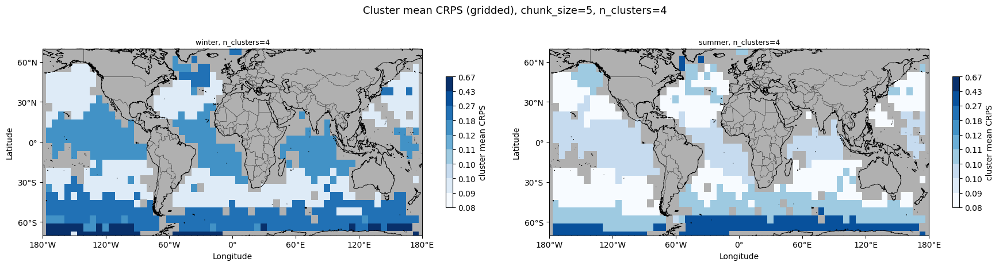

In [3]:
# ---- map view for ONE n_clusters value (and optionally one chunk_size) ----
# Set these and rerun the cell.
TARGET_N_CLUSTERS = 4     # <- change this
TARGET_CHUNK_SIZE = 5    # <- change this (must be one of chunk_sizes, e.g. 5, 10, 21)

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
from matplotlib.colors import ListedColormap, BoundaryNorm
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

DX = 6.0
LAT_CUTOFF_GRID = 80
DIST_THRESHOLD = 6.0
N_COLOR_BINS = 9

loni = np.arange(-180, 180 + DX, DX)
lati = np.arange(-70, 70 + DX, DX)
long, latg = np.meshgrid(loni, lati)
grid_points = np.column_stack([long.ravel(), latg.ravel()])

mask_data = np.load("../data/derived_crps/mask_to_plot_ratio.npz")
grid_mask = mask_data["mask"][:, :]
beyond_cutoff_grid = np.abs(lati) > LAT_CUTOFF_GRID
gray_cmap = ListedColormap(["#b0b0b0"])

def get_assigned_points(season, n_clusters, chunk_size):
    path = f"../data/regime_labels/cluster_coords_{season}_nclusters{n_clusters}.csv"
    cluster_df = pd.read_csv(path)
    cluster_coords = cluster_df[["longitude", "latitude"]].to_numpy()
    cluster_ids_ref = cluster_df["cluster"].to_numpy()
    cluster_tree = cKDTree(cluster_coords)

    crps_df = crps_rows_by_chunk_size[chunk_size]
    season_df = crps_df[crps_df["season"] == season].copy()
    query_coords = season_df[["lon", "lat"]].to_numpy()
    _, nearest_idx = cluster_tree.query(query_coords)
    season_df["cluster"] = cluster_ids_ref[nearest_idx]
    return season_df[["lat", "lon", "cluster", "crps"]]

proj = ccrs.PlateCarree()

fig, axes = plt.subplots(1, len(seasons), figsize=(9 * len(seasons), 4.5), subplot_kw={"projection": proj}, squeeze=False)

# shared color scale across winter/summer for this (n_clusters, chunk_size)
all_cluster_means = []
for season in seasons:
    summary = cluster_avg_results[(season, TARGET_N_CLUSTERS)]
    if TARGET_CHUNK_SIZE in summary.index.get_level_values("chunk_size"):
        all_cluster_means.extend(summary.loc[TARGET_CHUNK_SIZE, "mean_crps"].values)

quantiles = np.linspace(0, 1, N_COLOR_BINS + 1)
bin_edges = np.unique(np.quantile(all_cluster_means, quantiles))
if len(bin_edges) < 3:
    bin_edges = np.linspace(min(all_cluster_means), max(all_cluster_means) + 1e-9, 3)
discrete_cmap = plt.get_cmap("Blues", len(bin_edges) - 1)
norm = BoundaryNorm(bin_edges, discrete_cmap.N)

for col_idx, season in enumerate(seasons):
    ax = axes[0, col_idx]
    pts = get_assigned_points(season, TARGET_N_CLUSTERS, TARGET_CHUNK_SIZE)
    summary = cluster_avg_results[(season, TARGET_N_CLUSTERS)]

    cluster_mean_lookup = summary.loc[TARGET_CHUNK_SIZE, "mean_crps"].to_dict()
    point_vals = pts["cluster"].map(cluster_mean_lookup).to_numpy()

    coordinate = np.column_stack([pts["lon"].to_numpy(), pts["lat"].to_numpy()])
    gridded = griddata(coordinate, point_vals, (long, latg), method="nearest")

    tree = cKDTree(coordinate)
    dist_to_nearest, _ = tree.query(grid_points)
    too_far = dist_to_nearest.reshape(long.shape) > DIST_THRESHOLD
    gridded[too_far] = np.nan

    gridded = gridded * grid_mask
    gridded[grid_mask == 0] = np.nan
    gridded[beyond_cutoff_grid, :] = np.nan

    grayed_out = np.full_like(grid_mask, np.nan, dtype=float)
    grayed_out[grid_mask == 0] = 1.0
    grayed_out[beyond_cutoff_grid, :] = 1.0
    grayed_out[too_far] = 1.0

    mesh = ax.pcolor(loni, lati, gridded, cmap=discrete_cmap, norm=norm, transform=proj)
    cbar = plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS", boundaries=bin_edges, ticks=bin_edges)
    cbar.ax.set_yticklabels([f"{v:.2f}" for v in bin_edges])

    ax.pcolor(loni, lati, grayed_out, cmap=gray_cmap, vmin=0, vmax=1, transform=proj)
    ax.coastlines(resolution="50m", linewidth=0.7, color="black")
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, zorder=2)
    ax.set_xticks(np.arange(-180, 181, 60), crs=proj)
    ax.set_yticks(np.arange(-60, 61, 30), crs=proj)
    ax.xaxis.set_major_formatter(LONGITUDE_FORMATTER)
    ax.yaxis.set_major_formatter(LATITUDE_FORMATTER)

    ax.set_title(f"{season}, n_clusters={TARGET_N_CLUSTERS}", fontsize=9)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_extent([-180, 180, -70, 70], crs=proj)
    ax.set_aspect("auto")

plt.suptitle(f"Cluster mean CRPS (gridded), chunk_size={TARGET_CHUNK_SIZE}, n_clusters={TARGET_N_CLUSTERS}", fontsize=13, y=1.02)
plt.tight_layout()
out_path = f"crps_cluster_map_chunk{TARGET_CHUNK_SIZE}_nclusters{TARGET_N_CLUSTERS}.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()


In [ ]:
# ---- single-season map for a given (n_clusters, chunk_size, season) ----
# Call plot_cluster_map(n_clusters, chunk_size, season) with your inputs;
# each call produces one standalone figure (not a winter+summer pair) and
# prints/returns the exact per-cluster mean CRPS values used to color it.

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
from matplotlib.colors import ListedColormap, BoundaryNorm
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

DX = 6.0
LAT_CUTOFF_GRID = 80
DIST_THRESHOLD = 6.0
N_COLOR_BINS = 9

_loni = np.arange(-180, 180 + DX, DX)
_lati = np.arange(-70, 70 + DX, DX)
_long, _latg = np.meshgrid(_loni, _lati)
_grid_points = np.column_stack([_long.ravel(), _latg.ravel()])

_mask_data = np.load("mask_to_plot_ratio.npz")
_grid_mask = _mask_data["mask"][:, :]
_beyond_cutoff_grid = np.abs(_lati) > LAT_CUTOFF_GRID
_gray_cmap = ListedColormap(["#b0b0b0"])


def get_assigned_points(season, n_clusters, chunk_size):
    path = f"cluster_coordina_season_nclusters/cluster_coords_{season}_nclusters{n_clusters}.csv"
    cluster_df = pd.read_csv(path)
    cluster_coords = cluster_df[["longitude", "latitude"]].to_numpy()
    cluster_ids_ref = cluster_df["cluster"].to_numpy()
    cluster_tree = cKDTree(cluster_coords)

    crps_df = crps_rows_by_chunk_size[chunk_size]
    season_df = crps_df[crps_df["season"] == season].copy()
    query_coords = season_df[["lon", "lat"]].to_numpy()
    _, nearest_idx = cluster_tree.query(query_coords)
    season_df["cluster"] = cluster_ids_ref[nearest_idx]
    return season_df[["lat", "lon", "cluster", "crps"]]


def plot_cluster_map(n_clusters, chunk_size, season):
    proj = ccrs.PlateCarree()
    fig, ax = plt.subplots(1, 1, figsize=(9, 4.5), subplot_kw={"projection": proj})

    summary = cluster_avg_results[(season, n_clusters)]
    cluster_stats = summary.loc[chunk_size][["mean_crps", "std_crps", "n"]].sort_index()
    cluster_means = cluster_stats["mean_crps"].values

    print(f"Per-cluster mean CRPS -- season={season}, n_clusters={n_clusters}, chunk_size={chunk_size}")
    print(cluster_stats.to_string())

    quantiles = np.linspace(0, 1, N_COLOR_BINS + 1)
    bin_edges = np.unique(np.quantile(cluster_means, quantiles))
    if len(bin_edges) < 3:
        bin_edges = np.linspace(min(cluster_means), max(cluster_means) + 1e-9, 3)
    discrete_cmap = plt.get_cmap("Blues", len(bin_edges) - 1)
    norm = BoundaryNorm(bin_edges, discrete_cmap.N)

    pts = get_assigned_points(season, n_clusters, chunk_size)
    cluster_mean_lookup = summary.loc[chunk_size, "mean_crps"].to_dict()
    point_vals = pts["cluster"].map(cluster_mean_lookup).to_numpy()

    coordinate = np.column_stack([pts["lon"].to_numpy(), pts["lat"].to_numpy()])
    gridded = griddata(coordinate, point_vals, (_long, _latg), method="nearest")

    tree = cKDTree(coordinate)
    dist_to_nearest, _ = tree.query(_grid_points)
    too_far = dist_to_nearest.reshape(_long.shape) > DIST_THRESHOLD
    gridded[too_far] = np.nan

    gridded = gridded * _grid_mask
    gridded[_grid_mask == 0] = np.nan
    gridded[_beyond_cutoff_grid, :] = np.nan

    grayed_out = np.full_like(_grid_mask, np.nan, dtype=float)
    grayed_out[_grid_mask == 0] = 1.0
    grayed_out[_beyond_cutoff_grid, :] = 1.0
    grayed_out[too_far] = 1.0

    mesh = ax.pcolor(_loni, _lati, gridded, cmap=discrete_cmap, norm=norm, transform=proj)
    cbar = plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS", boundaries=bin_edges, ticks=bin_edges)
    cbar.ax.set_yticklabels([f"{v:.2f}" for v in bin_edges])

    ax.pcolor(_loni, _lati, grayed_out, cmap=_gray_cmap, vmin=0, vmax=1, transform=proj)
    ax.coastlines(resolution="50m", linewidth=0.7, color="black")
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, zorder=2)
    ax.set_xticks(np.arange(-180, 181, 60), crs=proj)
    ax.set_yticks(np.arange(-60, 61, 30), crs=proj)
    ax.xaxis.set_major_formatter(LONGITUDE_FORMATTER)
    ax.yaxis.set_major_formatter(LATITUDE_FORMATTER)

    ax.set_title(f"{season}, n_clusters={n_clusters}, chunk_size={chunk_size}", fontsize=10)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_extent([-180, 180, -70, 70], crs=proj)
    ax.set_aspect("auto")

    plt.tight_layout()
    out_path = f"crps_cluster_map_chunk{chunk_size}_nclusters{n_clusters}_{season}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_path}")

    csv_path = f"crps_cluster_map_chunk{chunk_size}_nclusters{n_clusters}_{season}_values.csv"
    cluster_stats.to_csv(csv_path)
    print(f"Saved: {csv_path}")

    plt.show()
    return cluster_stats


# ---- example usage: set your combo and call once per season ----
N_CLUSTERS = 4
CHUNK_SIZE = 5

winter_stats = plot_cluster_map(N_CLUSTERS, CHUNK_SIZE, "winter")
summer_stats = plot_cluster_map(N_CLUSTERS, CHUNK_SIZE, "summer")


/tmp/ipykernel_1607456/1726998070.py:78: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS", boundaries=bin_edges, ticks=bin_edges)


Saved: crps_cluster_map_chunk10_nclusters4_winter.png


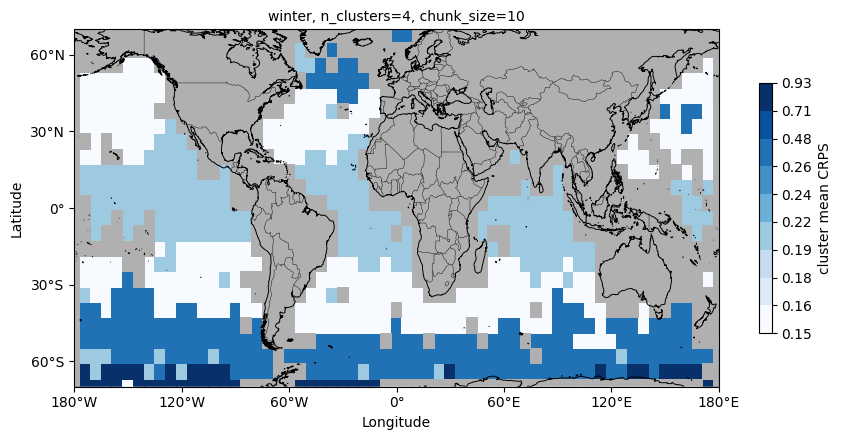

/tmp/ipykernel_1607456/1726998070.py:78: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS", boundaries=bin_edges, ticks=bin_edges)


Saved: crps_cluster_map_chunk10_nclusters4_summer.png


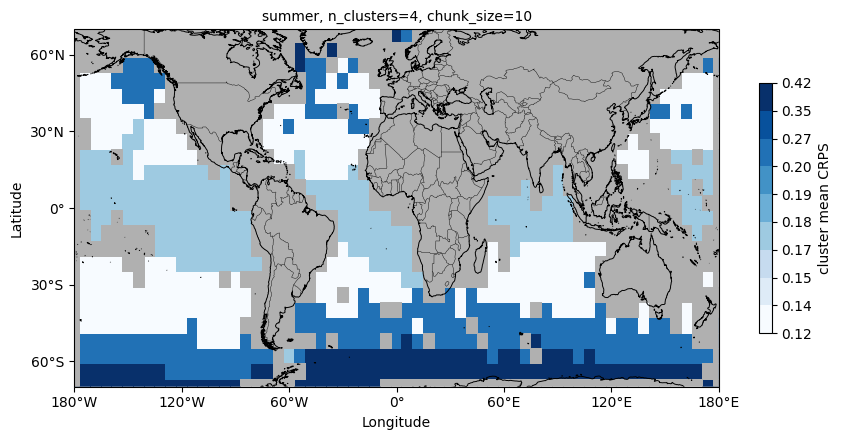

In [5]:
N_CLUSTERS = 4
CHUNK_SIZE = 10

plot_cluster_map(N_CLUSTERS, CHUNK_SIZE, "winter")
plot_cluster_map(N_CLUSTERS, CHUNK_SIZE, "summer")

/tmp/ipykernel_1607456/1726998070.py:78: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS", boundaries=bin_edges, ticks=bin_edges)


Saved: crps_cluster_map_chunk21_nclusters4_winter.png


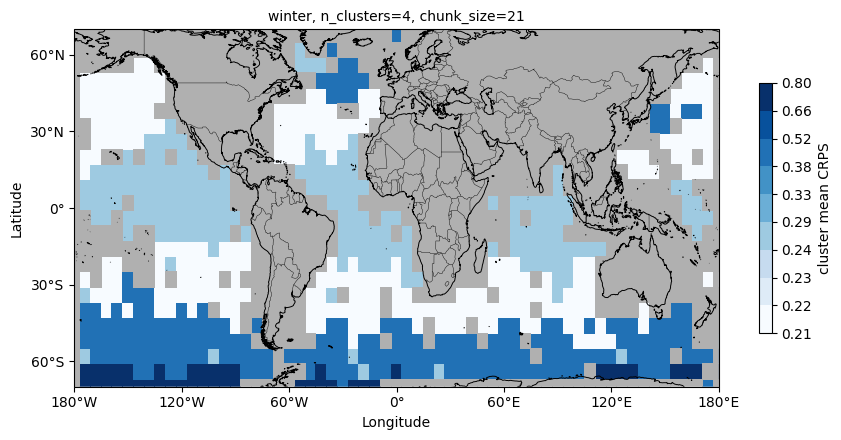

/tmp/ipykernel_1607456/1726998070.py:78: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(mesh, ax=ax, shrink=0.7, label="cluster mean CRPS", boundaries=bin_edges, ticks=bin_edges)


Saved: crps_cluster_map_chunk21_nclusters4_summer.png


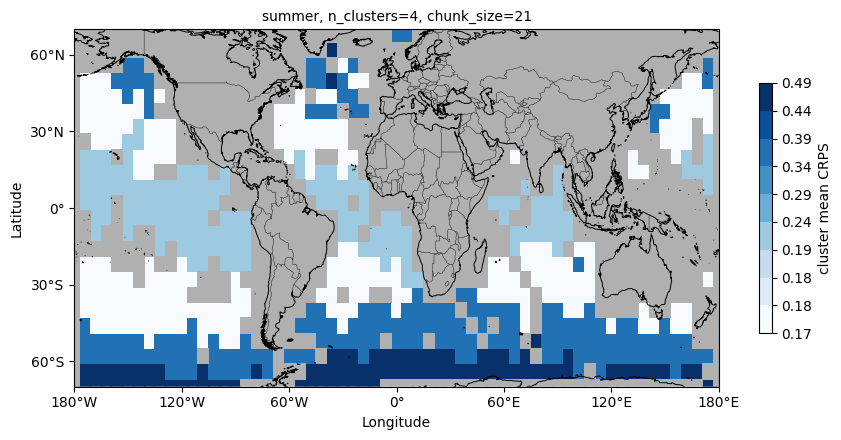

In [6]:
N_CLUSTERS = 4
CHUNK_SIZE = 21

plot_cluster_map(N_CLUSTERS, CHUNK_SIZE, "winter")
plot_cluster_map(N_CLUSTERS, CHUNK_SIZE, "summer")

In [ ]:
# ---- min/max of per-cluster mean CRPS, across clusters, for each ----
# ---- (season, n_clusters, chunk_size) configuration ----
# For a given config (e.g. winter, n_clusters=5, chunk_size=10), we have one
# mean_crps value per cluster (0..4). This takes the min and max of those
# per-cluster means -- i.e. "how far apart is the best cluster from the worst
# cluster" for that config -- NOT the spread of raw CRPS within a cluster.

range_rows = []
for (season, n_clusters), summary in cluster_avg_results.items():
    for chunk_size in chunk_sizes:
        if chunk_size not in summary.index.get_level_values("chunk_size"):
            continue
        cluster_means = summary.loc[chunk_size, "mean_crps"]
        range_rows.append({
            "season": season,
            "n_clusters": n_clusters,
            "chunk_size": chunk_size,
            "min_cluster_mean": cluster_means.min(),
            "max_cluster_mean": cluster_means.max(),
            "min_cluster_id": cluster_means.idxmin(),
            "max_cluster_id": cluster_means.idxmax(),
        })

cluster_range_df = pd.DataFrame(range_rows).sort_values(["season", "chunk_size", "n_clusters"]).reset_index(drop=True)
print("Min/max per-cluster mean CRPS, per (season, chunk_size, n_clusters):")
cluster_range_df

In [ ]:
# ---- plot: min-to-max range of per-cluster mean CRPS, vs n_clusters ----
# x-axis = n_clusters, one vertical range bar per chunk_size (min to max,
# dot at the midpoint), faceted by season (one subplot per season).

fig, axes = plt.subplots(1, len(seasons), figsize=(7 * len(seasons), 5), squeeze=False)

n_groups = len(chunk_sizes)
group_width = 0.8
bar_width = group_width / n_groups

for col_idx, season in enumerate(seasons):
    ax = axes[0, col_idx]
    season_df = cluster_range_df[cluster_range_df["season"] == season]

    for i, chunk_size in enumerate(chunk_sizes):
        sub = season_df[season_df["chunk_size"] == chunk_size].sort_values("n_clusters")
        offset = (i - (n_groups - 1) / 2) * bar_width
        x = sub["n_clusters"].to_numpy() + offset

        ax.vlines(x, sub["min_cluster_mean"], sub["max_cluster_mean"],
                  color=chunk_colors[chunk_size], linewidth=2.5, alpha=0.8)
        ax.scatter(x, sub["min_cluster_mean"], color=chunk_colors[chunk_size], marker="v", s=25, zorder=3)
        ax.scatter(x, sub["max_cluster_mean"], color=chunk_colors[chunk_size], marker="^", s=25, zorder=3,
                   label=f"chunk_size={chunk_size}")

    ax.set_xticks(sorted(cluster_range_df["n_clusters"].unique()))
    ax.set_xlabel("n_clusters")
    ax.set_ylabel("cluster mean CRPS (min to max)")
    ax.set_title(f"{season}", fontsize=11)
    ax.grid(True, ls="--", lw=0.4, alpha=0.6)
    if col_idx == 0:
        ax.legend(fontsize=8)

plt.suptitle("Best-to-worst cluster CRPS range vs n_clusters, by chunk_size", fontsize=13)
plt.tight_layout()
plt.savefig("crps_cluster_minmax_range.png", dpi=150, bbox_inches="tight")
print("Saved: crps_cluster_minmax_range.png")
plt.show()